Fitting 10 folds for each of 360 candidates, totalling 3600 fits
En iyi parametreler: {'C': 10, 'coef0': 0.0, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}
Modelin Doğruluk Oranı: 0.9707602339181286
Siniflandirma Raporu:
               precision    recall  f1-score   support

      Benign       0.96      0.99      0.98       107
   Malignant       0.98      0.94      0.96        64

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



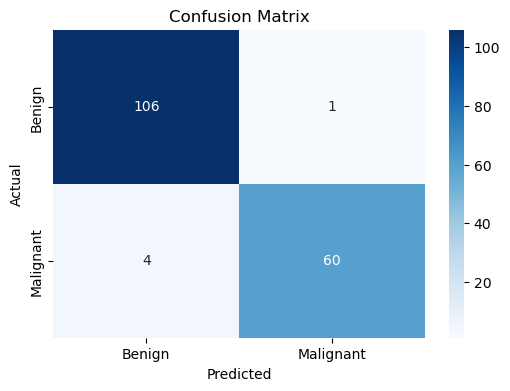

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns

dosya_yolu="../data/raw/data.csv"
data=pd.read_csv(dosya_yolu)

# on islem
data.drop(["id","Unnamed: 32"],axis=1,inplace=True)
label_encoder= LabelEncoder()
data["diagnosis"]=label_encoder.fit_transform(data["diagnosis"])
X=data.drop("diagnosis",axis=1)
y=data["diagnosis"]
sc=StandardScaler()
X_scaled=sc.fit_transform(X)
X_train,X_test,y_train,y_test=train_test_split(X_scaled,
                                               y,
                                               test_size=0.3,
                                               random_state=42,
                                               stratify=y
                                               )
svc=SVC()
param_grid= {
    "C":[0.1,1,10,100,1000],
    "kernel":["linear","poly","rbf","sigmoid"],
    "degree":[2,3,4],
    "gamma":["scale","auto"],
    "coef0":[0.0,0.1,0.5]
}
grid_search=GridSearchCV(estimator=svc,
                         param_grid=param_grid,
                         scoring="accuracy",
                         cv=10,
                         verbose=1,
                         n_jobs=-1
)
grid_search.fit(X_train,y_train)

best_model= grid_search.best_estimator_
best_params= grid_search.best_params_

print(f"En iyi parametreler: {best_params}")
y_pred=best_model.predict(X_test)
accuracy=best_model.score(X_test,y_test)
print(f"Modelin Doğruluk Oranı: {accuracy}")

cm=confusion_matrix(y_test,y_pred)
cr=classification_report(y_test,
                         y_pred,
                         target_names=["Benign","Malignant"])
print("Siniflandirma Raporu:\n",cr)

plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
            xticklabels=["Benign","Malignant"],
            yticklabels=["Benign","Malignant"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

C:\Users\emirs\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Sistem belirtilen dosyayı bulamıyor
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\emirs\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\emirs\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\emirs\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^

diagnosis
0    357
1    212
Name: count, dtype: int64
diagnosis
1    357
0    357
Name: count, dtype: int64
Secilen Ozellikler:
Index(['radius_mean', 'perimeter_mean', 'area_mean', 'concavity_mean',
       'concave points_mean', 'radius_worst', 'perimeter_worst', 'area_worst',
       'concavity_worst', 'concave points_worst'],
      dtype='object')
Logistic Regression Accuracy: 0.972028
Random Forest Accuracy: 0.972028
SVM Accuracy: 0.986014
K-Nearest Neighbors Accuracy: 0.965035
Decision Tree Accuracy: 0.937063
Gradient Boosting Accuracy: 0.958042
AdaBoost Accuracy: 0.944056
Naive Bayes Accuracy: 0.951049


C:\Users\emirs\AppData\Local\Temp\ipykernel_19816\3466525111.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Accuracy",y="Model",data=accuracies_df, palette="viridis")


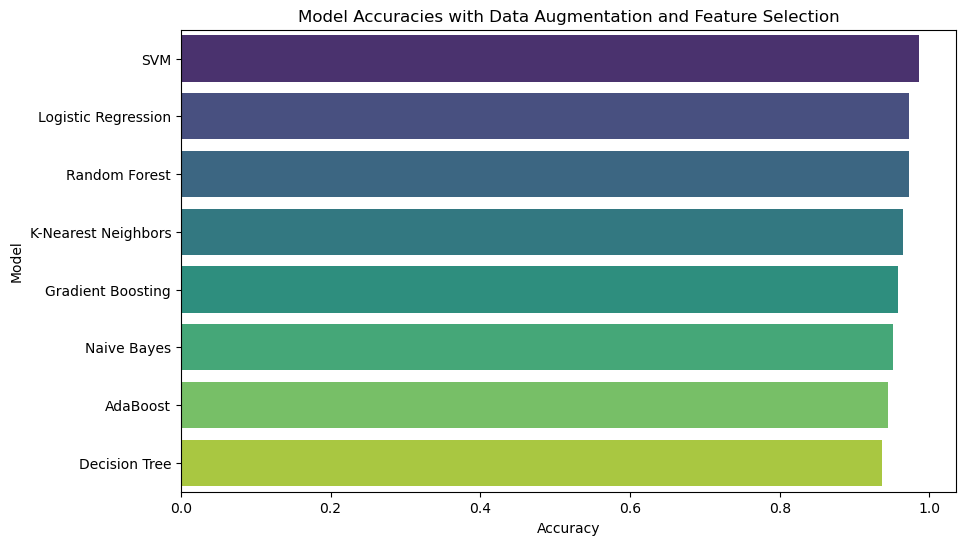

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.svm import  SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
import seaborn as sns

dosya_yolu="../data/raw/data.csv"
data=pd.read_csv(dosya_yolu)

data.drop(["id","Unnamed: 32"],axis=1,inplace=True)
label_encoder= LabelEncoder()
data["diagnosis"]=label_encoder.fit_transform(data["diagnosis"])
X=data.drop("diagnosis",axis=1)
y=data["diagnosis"]
scaler= StandardScaler()
X_scaled=scaler.fit_transform(X)

smote= SMOTE(random_state=42)
#smote= SMOTE(sampling_strategy=0.5,random_state=42)
#smote= SMOTE(sampling_strategy={1:300},random_state=42)

X_augmented,y_augmented=smote.fit_resample(X_scaled,y)

print(y.value_counts())
print(y_augmented.value_counts())

k_best_selector= SelectKBest(score_func=f_classif,k=10)
X_selected=k_best_selector.fit_transform(X_augmented,y_augmented)

# Fix: Apply get_support() to the original feature names from X
selected_features=X.columns[k_best_selector.get_support()]
print("Secilen Ozellikler:")
print(selected_features)

X_train, X_test, y_train, y_test = train_test_split(X_selected,
                                                    y_augmented,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y_augmented)
models ={
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Naive Bayes": GaussianNB()
}

accuracies=[]
for model_name,model in models.items():
  model.fit(X_train,y_train)
  y_pred=model.predict(X_test)
  accuracy=accuracy_score(y_test,y_pred)
  accuracies.append((model_name,accuracy))
  print(f"{model_name} Accuracy: {accuracy:4f}")

accuracies_df=pd.DataFrame(accuracies,
                           columns=["Model","Accuracy"]).sort_values(by="Accuracy",
                                                                     ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Accuracy",y="Model",data=accuracies_df, palette="viridis")
plt.title("Model Accuracies with Data Augmentation and Feature Selection")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.show()